In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,24-01-2011,27.318001,27.459999,26.955000,27.174999,168
1,25-01-2011,26.811001,26.950001,26.565001,26.915001,77
2,26-01-2011,27.132000,27.025000,26.684999,27.025000,49
3,27-01-2011,27.045000,27.684999,27.410000,27.684999,184
4,28-01-2011,27.934000,27.950001,26.504999,26.695000,64


In [ ]:
df.shape

(3768, 6)

In [ ]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB


In [ ]:
df.describe()

,Close,High,Low,Open,Volume
count,3768.000000,3768.000000,3768.000000,3768.000000,3768.000000
mean,23.497272,23.684994,23.314177,23.503893,1815.771231
std,8.690819,8.845847,8.520700,8.678501,10201.389877
min,11.735000,12.205000,11.735000,12.070000,0.000000
25%,16.947750,17.017999,16.869501,16.928750,10.000000
50%,21.737000,21.864500,21.595000,21.730499,48.000000
75%,27.967750,28.126250,27.724999,27.905000,168.000000
max,91.875999,93.000000,88.705002,90.824997,170297.000000


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_18042/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df = df.sort_values(by='Date')

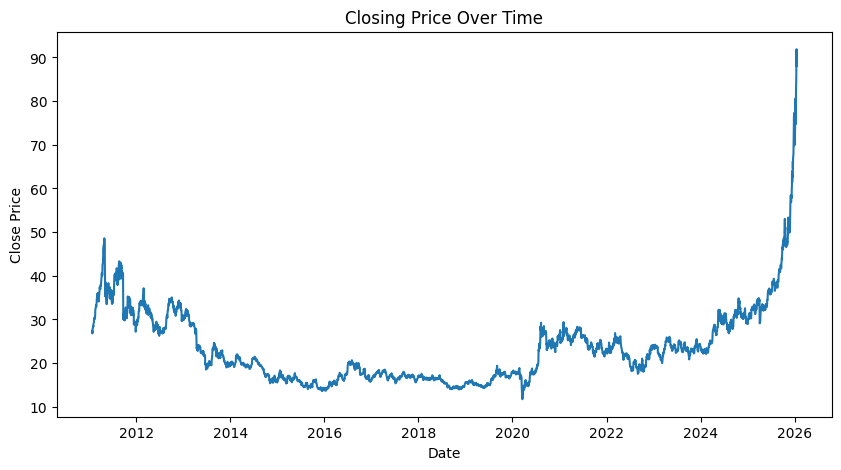

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

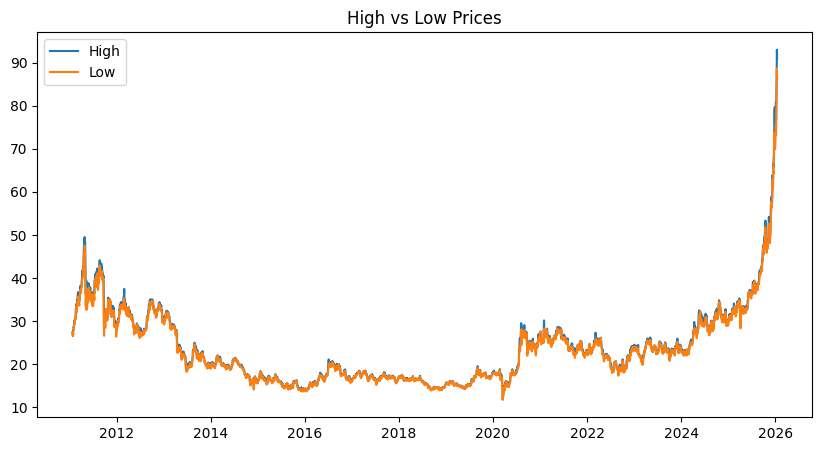

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')
plt.title("High vs Low Prices")
plt.legend()
plt.show()

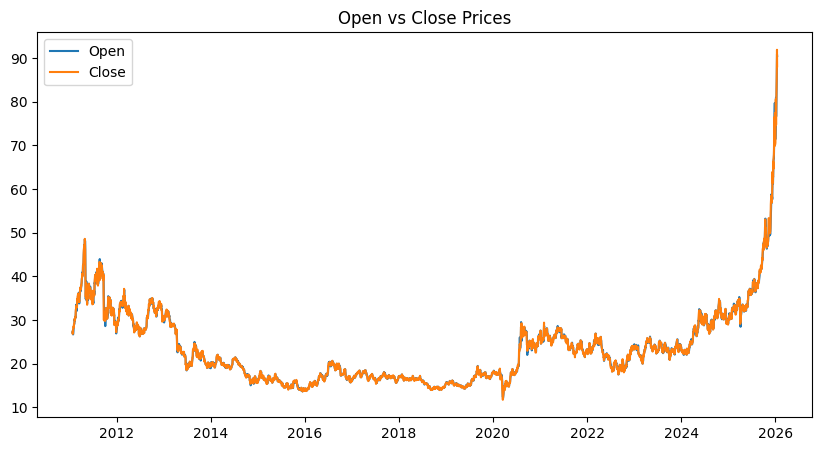

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')
plt.title("Open vs Close Prices")
plt.legend()
plt.show()

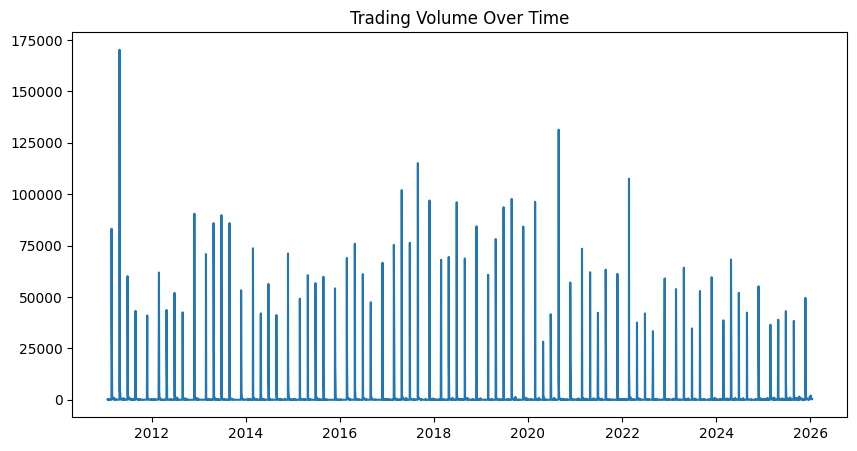

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume Over Time")
plt.show()

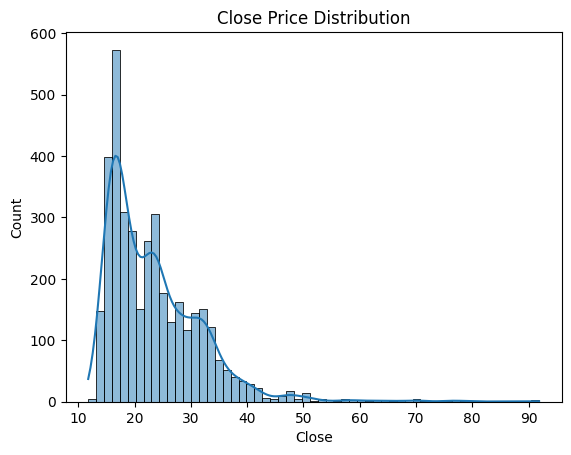

In [ ]:
plt.figure()
sns.histplot(df['Close'], kde=True)
plt.title("Close Price Distribution")
plt.show()

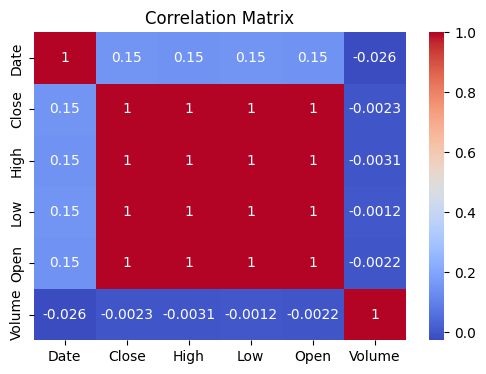

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df['Price_Change'] = df['Close'] - df['Open']

In [ ]:
df['MA_10'] = df['Close'].rolling(window=10).mean()

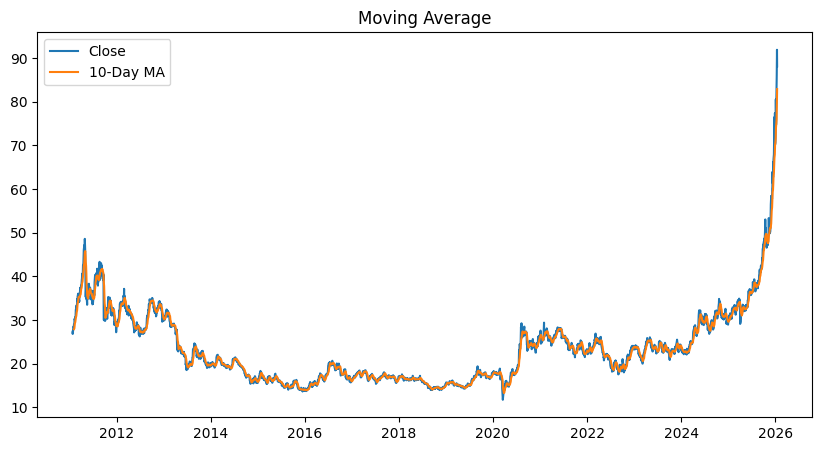

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_10'], label='10-Day MA')
plt.legend()
plt.title("Moving Average")
plt.show()

In [ ]:
df.to_csv("cleaned_stock_data.csv", index=False)

In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume,Price_Change,MA_10
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168,0.143002,NaN
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77,-0.104000,NaN
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49,0.107000,NaN
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184,-0.639999,NaN
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64,1.239000,NaN


In [ ]:
# ================================
# ASSIGNMENT 2: DATASET OVERVIEW & FEATURE CLASSIFICATION
# ================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np


# Step 3: Load Dataset
# Replace filename if needed
df = pd.read_csv('silver_prices_data.csv')

# Step 4: Basic Overview
print("\n===== DATASET HEAD =====")
print(df.head())

print("\n===== DATASET INFO =====")
print(df.info())

print("\n===== DATASET SHAPE =====")
print(df.shape)

# Step 5: Feature Classification Function
def classify_column(col):
    if df[col].dtype == 'object':
        return "Categorical (Nominal)"
    elif np.issubdtype(df[col].dtype, np.integer):
        unique_vals = df[col].nunique()
        if unique_vals < 20:
            return "Categorical (Ordinal/Discrete)"
        else:
            return "Numerical (Discrete)"
    elif np.issubdtype(df[col].dtype, np.floating):
        return "Numerical (Continuous)"
    elif 'date' in col.lower():
        return "Date/Time"
    else:
        return "Unknown"

# Step 6: Create Feature Classification Table
feature_summary = []

for col in df.columns:
    feature_type = classify_column(col)
    example_value = df[col].dropna().iloc[0]

    feature_summary.append({
        "Column Name": col,
        "Data Type": str(df[col].dtype),
        "Feature Type": feature_type,
        "Example Value": example_value
    })

feature_df = pd.DataFrame(feature_summary)

print("\n===== FEATURE CLASSIFICATION =====")
print(feature_df)

# Step 7: Add Meaning of Columns (Manually based on Silver Dataset)
column_meaning = {
    "Date": "Trading date",
    "Open": "Opening price of silver",
    "High": "Highest price of the day",
    "Low": "Lowest price of the day",
    "Close": "Closing price of the day",
    "Adj Close": "Adjusted closing price",
    "Volume": "Number of shares traded"
}

feature_df["Meaning"] = feature_df["Column Name"].map(column_meaning)

print("\n===== FEATURE DETAILS WITH MEANING =====")
print(feature_df)

# Step 8: Identify Target Variable
target_variable = "Close"  # You can change if needed

print("\n===== TARGET VARIABLE =====")
print("Target Variable:", target_variable)

# Step 9: Class Distribution
print("\n===== CLASS DISTRIBUTION =====")

if df[target_variable].dtype == 'object':
    print(df[target_variable].value_counts())
else:
    print(df[target_variable].describe())

# Step 10: Save Output (Optional)
feature_df.to_csv("feature_classification_output.csv", index=False)
print("\nFile saved as 'feature_classification_output.csv'")


===== DATASET HEAD =====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3768 non-null   object 
 1   Close   3768 non-null   float64
 2   High    3768 non-null   float64
 3   Low     3768 non-null   float64
 4   Open    3768 non-null   float64
 5   Volume  3768 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.8+ KB
None

===== DATASET SHAPE =====
(3768, 6)

===== FEATURE CLASSIFICATION =====
  Column

In [ ]:
import pandas as pd
import numpy as np

# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== DATASET LOADED ===音が")
print(df.head())

# --------------------------------------------
# Step 3: Initialize Report List
# --------------------------------------------
report = []

# --------------------------------------------
# Step 4: Missing Values Check
# --------------------------------------------
missing = df.isnull().sum()

for col in missing.index:
    if missing[col] > 0:
        report.append({
            "Issue": "Missing Values",
            "Column": col,
            "Affected Records": missing[col],
            "Suggested Action": "Use imputation (mean/median) or drop rows"
        })

# --------------------------------------------
# Step 5: Duplicate Records Check
# --------------------------------------------
duplicates = df.duplicated().sum()

if duplicates > 0:
    report.append({
        "Issue": "Duplicate Records",
        "Column": "All Columns",
        "Affected Records": duplicates,
        "Suggested Action": "Remove duplicates using drop_duplicates()"
    })

# --------------------------------------------
# Step 6: Identifier / Irrelevant Columns
# --------------------------------------------
for col in df.columns:
    unique_vals = df[col].nunique()

    if unique_vals == len(df):
        report.append({
            "Issue": "Identifier Column",
            "Column": col,
            "Affected Records": unique_vals,
            "Suggested Action": "Consider dropping if not useful for analysis"
        })

# --------------------------------------------
# Step 7: Data Type Issues
# --------------------------------------------
for col in df.columns:
    if df[col].dtype == 'object':
        # Check if numeric stored as string
        try:
            pd.to_numeric(df[col])
            report.append({
                "Issue": "Inconsistent Data Type",
                "Column": col,
                "Affected Records": len(df),
                "Suggested Action": "Convert to numeric using pd.to_numeric()"
            })
        except:
            pass

# --------------------------------------------
# Step 8: Date Column Check
# --------------------------------------------
for col in df.columns:
    if 'date' in col.lower():
        try:
            df[col] = pd.to_datetime(df[col])
        except:
            report.append({
                "Issue": "Date Format Issue",
                "Column": col,
                "Affected Records": len(df),
                "Suggested Action": "Convert using pd.to_datetime()"
            })

# --------------------------------------------
# Step 9: Class Imbalance Check
# --------------------------------------------
target = "Close"  # Change if needed

if target in df.columns:
    if df[target].dtype == 'object':
        class_counts = df[target].value_counts()
        imbalance_ratio = class_counts.max() / class_counts.min()

        if imbalance_ratio > 2:
            report.append({
                "Issue": "Class Imbalance",
                "Column": target,
                "Affected Records": len(df),
                "Suggested Action": "Use resampling techniques (SMOTE/undersampling)"
            })
    else:
        report.append({
            "Issue": "No Class Imbalance",
            "Column": target,
            "Affected Records": len(df),
            "Suggested Action": "Target is continuous (regression problem)"
        })

# --------------------------------------------
# Step 10: Create Report DataFrame
# --------------------------------------------
report_df = pd.DataFrame(report)

print("\n===== DATA QUALITY REPORT =====")
print(report_df)

# --------------------------------------------
# Step 11: Save Report
# --------------------------------------------
report_df.to_csv("data_quality_report.csv", index=False)
print("\nReport saved as 'data_quality_report.csv'")


===== DATASET LOADED ===音が
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

===== DATA QUALITY REPORT =====
                Issue Column  Affected Records  \
0   Identifier Column   Date              3768   
1  No Class Imbalance  Close              3768   

                               Suggested Action  
0  Consider dropping if not useful for analysis  
1     Target is continuous (regression problem)  

Report saved as 'data_quality_report.csv'


In [ ]:
# ============================================
# ASSIGNMENT 4: DESCRIPTIVE STATISTICS & DATA SUMMARY
# ============================================

import pandas as pd
import numpy as np



# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== DATASET LOADED ====")
print(df.head())

# --------------------------------------------
# Step 3: Separate Numerical & Categorical Columns
# --------------------------------------------
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nNumerical Columns:", list(numerical_cols))
print("Categorical Columns:", list(categorical_cols))

# --------------------------------------------
# Step 4: Descriptive Statistics for Numerical Columns
# --------------------------------------------
print("\n===== NUMERICAL STATISTICS ====")

num_stats = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Std Dev": df[numerical_cols].std(),
    "Min": df[numerical_cols].min(),
    "Max": df[numerical_cols].max()
})

print(num_stats)

# --------------------------------------------
# Step 5: Descriptive Statistics for Categorical Columns
# --------------------------------------------
print("\n===== CATEGORICAL STATISTICS ====")

cat_summary = []

for col in categorical_cols:
    mode_val = df[col].mode()[0]
    value_counts = df[col].value_counts().head(5)  # top 5

    cat_summary.append({
        "Column": col,
        "Mode": mode_val,
        "Top Values": str(value_counts.to_dict())
    })

cat_stats = pd.DataFrame(cat_summary)

print(cat_stats)

# --------------------------------------------
# Step 6: Observations (Auto-generated)
# --------------------------------------------
print("\n===== INITIAL OBSERVATIONS ====")

for col in numerical_cols:
    print(f"\n🔹 Column: {col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Min: {df[col].min():.2f}")
    print(f"Max: {df[col].max():.2f}")

    if df[col].mean() > df[col].median():
        print("→ Slight right skew (possible high-value outliers)")
    elif df[col].mean() < df[col].median():
        print("→ Slight left skew")
    else:
        print("→ Symmetric distribution")

# --------------------------------------------
# Step 7: Save Results
# --------------------------------------------
num_stats.to_csv("numerical_statistics.csv")
cat_stats.to_csv("categorical_statistics.csv")

print("\nFiles saved: numerical_statistics.csv & categorical_statistics.csv")


===== DATASET LOADED ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

Numerical Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Categorical Columns: ['Date']

===== NUMERICAL STATISTICS ====
               Mean     Median       Std Dev     Min            Max
Close     23.497272  21.737000      8.690819  11.735      91.875999
High      23.684994  21.864500      8.845847  12.205      93.000000
Low       23.314177  21.595000      8.520700  11.735      88.705002
Open      23.503893  21.730499      8.678501  12.070      90.824997
Volume  1815.771231  48.000000  10201.389877   0.000  170297.000000

===== CATEGORICAL STATISTICS ====
  Column

In [ ]:
# ============================================
# ASSIGNMENT 6: DATA CLEANING & MISSING VALUE TREATMENT
# ============================================

import pandas as pd
import numpy as np


# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== ORIGINAL DATA ====")
print(df.head())

# --------------------------------------------
# Step 3: Check Missing Values
# --------------------------------------------
print("\n===== MISSING VALUES BEFORE CLEANING ====")
print(df.isnull().sum())

# --------------------------------------------
# Step 4: Handle Missing Values
# --------------------------------------------

# Numerical columns → fill with median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n===== MISSING VALUES AFTER TREATMENT ====")
print(df.isnull().sum())

# --------------------------------------------
# Step 5: Convert Date Column to Datetime
# --------------------------------------------
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col])
        print(f"\nConverted {col} to datetime")

# --------------------------------------------
# Step 6: Remove Duplicate Records
# --------------------------------------------
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"\nDuplicates Removed: {before - after}")

# --------------------------------------------
# Step 7: Outlier Detection (IQR Method)
# --------------------------------------------
print("\n===== OUTLIER DETECTION ====")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print(f"{col}: {outliers} outliers")

# --------------------------------------------
# Step 8: Optional Outlier Treatment (Capping)
# --------------------------------------------
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nOutliers capped using IQR method")

# --------------------------------------------
# Step 9: Final Clean Dataset
# --------------------------------------------
print("\n===== CLEANED DATA ====")
print(df.head())

# --------------------------------------------
# Step 10: Save Cleaned Dataset
# --------------------------------------------
df.to_csv("cleaned_silver_dataset.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_silver_dataset.csv'")


===== ORIGINAL DATA ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

===== MISSING VALUES BEFORE CLEANING ====
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

===== MISSING VALUES AFTER TREATMENT ====
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Converted Date to datetime

Duplicates Removed: 0

===== OUTLIER DETECTION ====
Close: 86 outliers
High: 88 outliers
Low: 85 outliers
Open: 86 outliers
Volume: 483 outliers

Outliers capped using IQR method

===== CLEANED DATA ====
        Date      Close       High        Low       Open  Volume
0 2011-01-24  27.318001 

In [ ]:
# ============================================
# ASSIGNMENT 7: ENCODING CATEGORICAL VARIABLES
# ============================================

import pandas as pd
import numpy as np

# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== ORIGINAL DATA ====")
print(df.head())

# --------------------------------------------
# Step 3: Check Categorical Columns
# --------------------------------------------
cat_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:", list(cat_cols))

# --------------------------------------------
# Step 4: Convert Date Column to Datetime
# --------------------------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

    # Extract features from Date
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

    print("\nExtracted Year, Month, Day from Date")

# --------------------------------------------
# Step 5: Drop Original Date Column (optional)
# --------------------------------------------
df.drop(columns=['Date'], inplace=True)

# --------------------------------------------
# Step 6: Encoding Categorical Variables
# --------------------------------------------
# In this dataset, Year/Month/Day are numerical already
# If categorical existed, we would use:

# Example (not needed here but for assignment):
# df = pd.get_dummies(df, columns=['column_name'])

print("\n===== DATA AFTER ENCODING ====")
print(df.head())

# --------------------------------------------
# Step 7: Save Processed Data
# --------------------------------------------
df.to_csv("encoded_dataset.csv", index=False)
print("\nEncoded dataset saved as 'encoded_dataset.csv'")


===== ORIGINAL DATA ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

Categorical Columns: ['Date']

Extracted Year, Month, Day from Date

===== DATA AFTER ENCODING ====
       Close       High        Low       Open  Volume  Year  Month  Day
0  27.318001  27.459999  26.955000  27.174999     168  2011      1   24
1  26.811001  26.950001  26.565001  26.915001      77  2011      1   25
2  27.132000  27.025000  26.684999  27.025000      49  2011      1   26
3  27.045000  27.684999  27.410000  27.684999     184  2011      1   27
4  27.934000  27.950001  26.504999  26.695000      64  2011      1   28

Encoded dataset saved as 'encoded_dataset.cs

In [ ]:
# ============================================
# ASSIGNMENT 8: FEATURE SCALING & FEATURE ENGINEERING
# ============================================

import pandas as pd
import numpy as np


# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== ORIGINAL DATA ====")
print(df.head())

# --------------------------------------------
# Step 3: Convert Date & Extract Features
# --------------------------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

# --------------------------------------------
# Step 4: FEATURE ENGINEERING
# --------------------------------------------

# 1. Price Range (Volatility)
df['Price_Range'] = df['High'] - df['Low']

# 2. Daily Return
df['Daily_Return'] = (df['Close'] - df['Open']) / df['Open']

# 3. Moving Average (7-day)
df['MA_7'] = df['Close'].rolling(window=7).mean()

# Fill NaN created by rolling
df['MA_7'] = df['MA_7'].fillna(df['MA_7'].mean())

print("\n===== AFTER FEATURE ENGINEERING ====")
print(df.head())

# --------------------------------------------
# Step 5: FEATURE SCALING
# --------------------------------------------
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

# -------- Standardization --------
scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])

print("\n===== STANDARDIZED DATA ====")
print(df_std.head())

# -------- Normalization --------
scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])

print("\n===== NORMALIZED DATA ====")
print(df_mm.head())

# --------------------------------------------
# Step 6: Save Outputs
# --------------------------------------------
df.to_csv("feature_engineered_dataset.csv", index=False)
df_std.to_csv("standardized_dataset.csv", index=False)
df_mm.to_csv("normalized_dataset.csv", index=False)

print("\nFiles saved:")
print("1. feature_engineered_dataset.csv")
print("2. standardized_dataset.csv")
print("3. normalized_dataset.csv")


===== ORIGINAL DATA ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

===== AFTER FEATURE ENGINEERING ====
        Date      Close       High        Low       Open  Volume  Year  Month  \
0 2011-01-24  27.318001  27.459999  26.955000  27.174999     168  2011      1   
1 2011-01-25  26.811001  26.950001  26.565001  26.915001      77  2011      1   
2 2011-01-26  27.132000  27.025000  26.684999  27.025000      49  2011      1   
3 2011-01-27  27.045000  27.684999  27.410000  27.684999     184  2011      1   
4 2011-01-28  27.934000  27.950001  26.504999  26.695000      64  2011      1   

   Day  Price_Range  Daily_Return       MA_7  
0   24


===== DATASET LOADED ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

Numerical Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

===== SUMMARY STATISTICS ====
             Close         High          Low         Open         Volume
count  3768.000000  3768.000000  3768.000000  3768.000000    3768.000000
mean     23.497272    23.684994    23.314177    23.503893    1815.771231
std       8.690819     8.845847     8.520700     8.678501   10201.389877
min      11.735000    12.205000    11.735000    12.070000       0.000000
25%      16.947750    17.017999    16.869501    16.928750      10.000000
50%      21.737000    21.864500    21.595000 

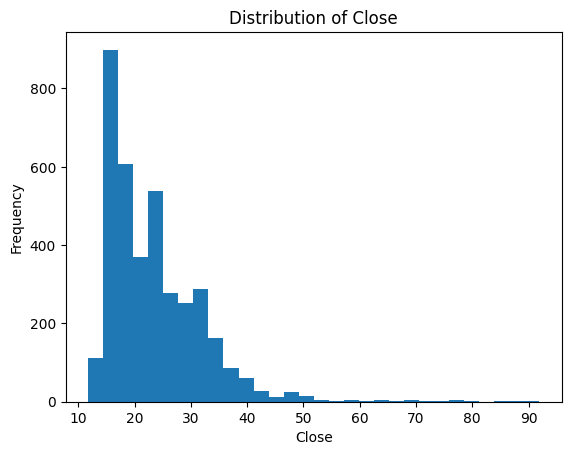

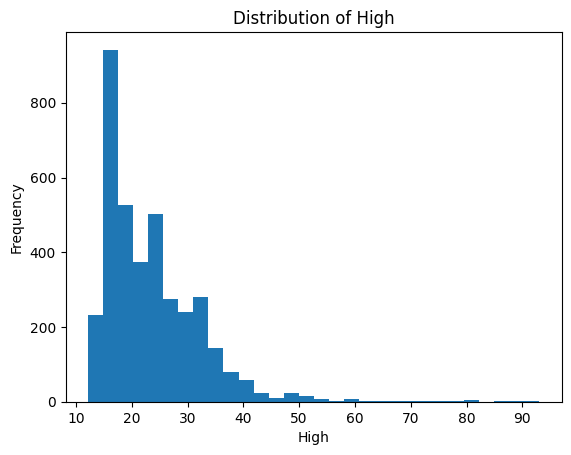

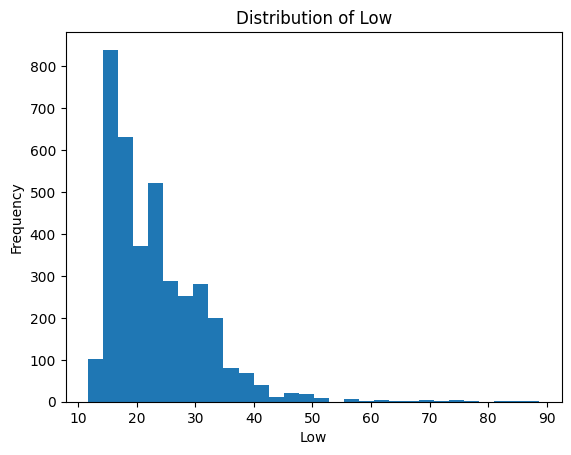

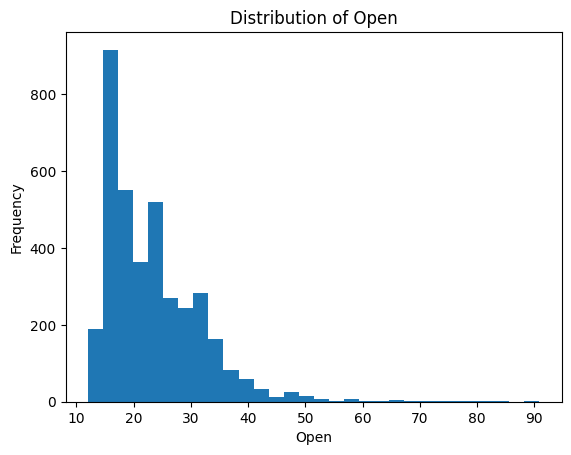

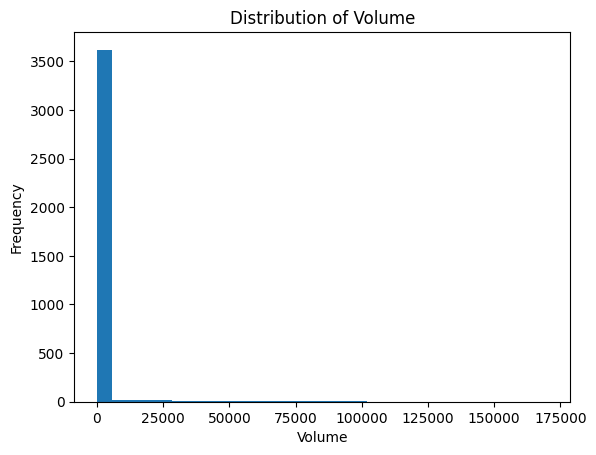

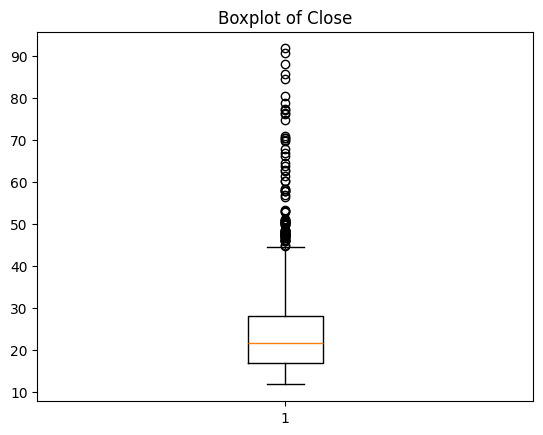

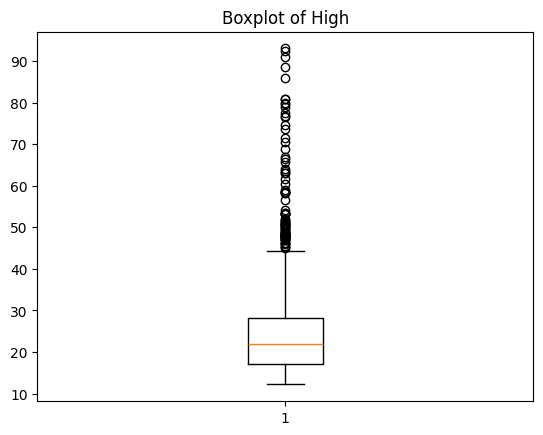

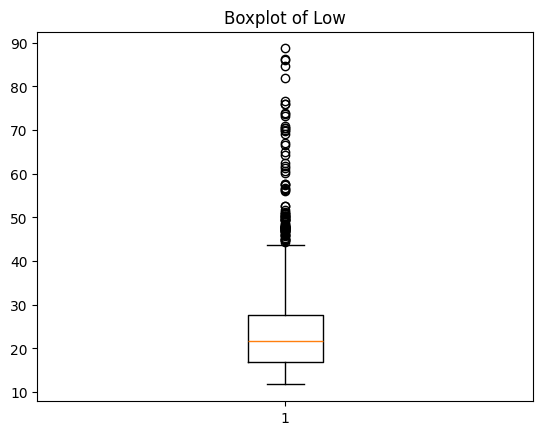

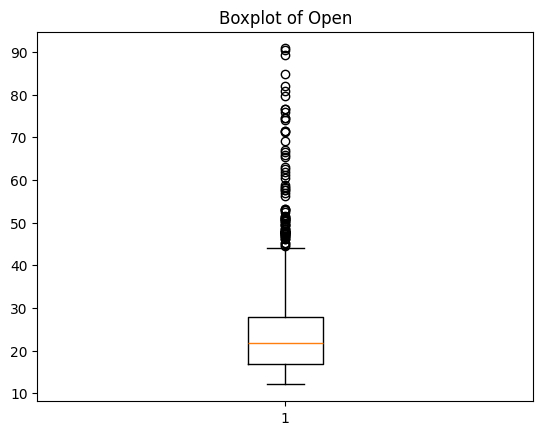

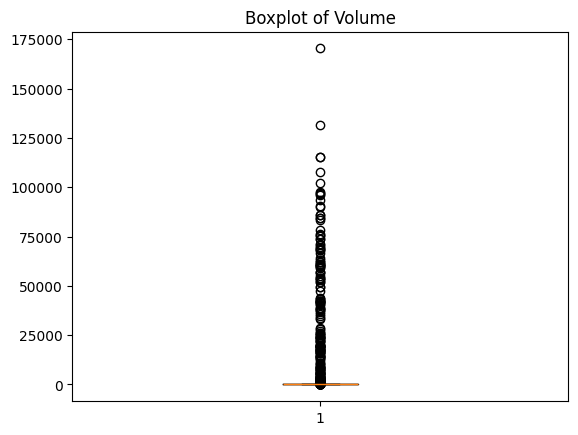


===== CORRELATION MATRIX ====
           Close      High       Low      Open    Volume
Close   1.000000  0.999133  0.999354  0.998465 -0.002250
High    0.999133  1.000000  0.998622  0.999381 -0.003069
Low     0.999354  0.998622  1.000000  0.998890 -0.001192
Open    0.998465  0.999381  0.998890  1.000000 -0.002241
Volume -0.002250 -0.003069 -0.001192 -0.002241  1.000000


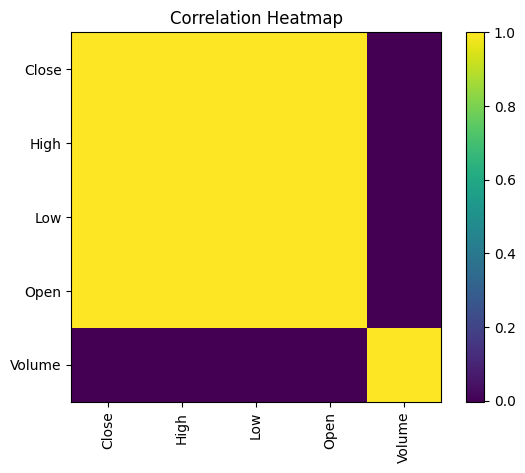

In [ ]:
# ============================================
# ASSIGNMENT: EDA — NUMERICAL FEATURE ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== DATASET LOADED ====")
print(df.head())

# --------------------------------------------
# Step 3: Select Numerical Columns
# --------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:", list(num_cols))

# --------------------------------------------
# Step 4: Summary Statistics
# --------------------------------------------
print("\n===== SUMMARY STATISTICS ====")
print(df[num_cols].describe())

# --------------------------------------------
# Step 5: Distribution Plots (Histogram)
# --------------------------------------------
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# --------------------------------------------
# Step 6: Boxplots (Outlier Detection)
# --------------------------------------------
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# --------------------------------------------
# Step 7: Correlation Matrix
# --------------------------------------------
corr = df[num_cols].corr()

print("\n===== CORRELATION MATRIX ====")
print(corr)

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap")
plt.show()


===== DATASET LOADED ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

Categorical Features: ['Year', 'Month']

===== VALUE COUNTS: Year ====
Year
2020    253
2014    252
2015    252
2013    252
2024    252
2021    252
2019    252
2025    252
2017    251
2022    251
2012    250
2016    250
2023    250
2018    250
2011    238
2026     11
Name: count, dtype: int64

===== VALUE COUNTS: Month ====
Month
8     333
10    330
3     327
5     319
7     318
6     316
12    315
4     310
9     306
11    305
1     301
2     288
Name: count, dtype: int64


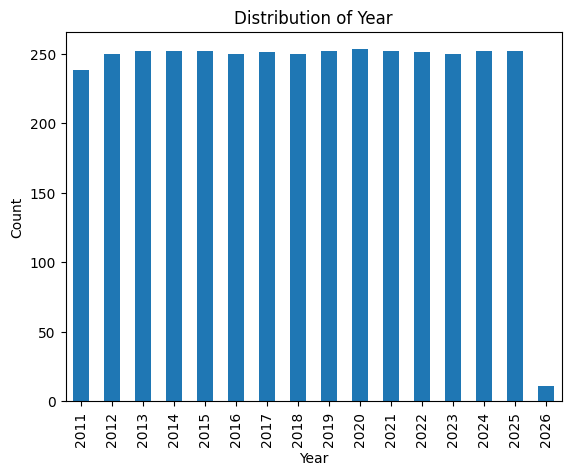

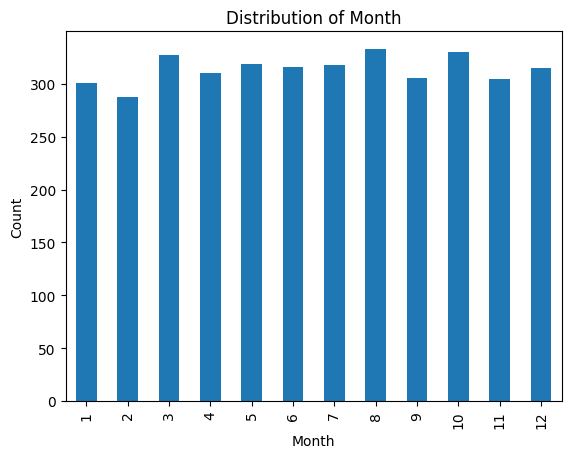


===== AVERAGE Close BY Year ====
Year
2011    35.618004
2012    31.141036
2013    23.746944
2014    19.030373
2015    15.657583
2016    17.133764
2017    17.020637
2018    15.648416
2019    16.159873
2020    20.648972
2021    25.141837
2022    21.756753
2023    23.391176
2024    28.295258
2025    40.124544
2026    81.755274
Name: Close, dtype: float64


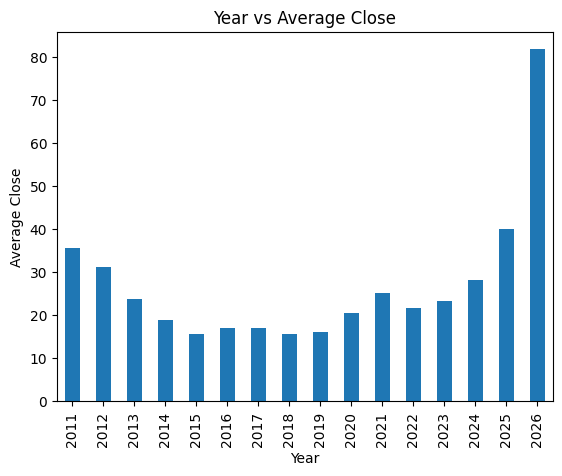


===== AVERAGE Close BY Month ====
Month
1     24.270711
2     22.938378
3     23.012878
4     23.384584
5     22.788022
6     22.714367
7     23.084340
8     23.651703
9     24.012013
10    23.834703
11    23.750000
12    24.541965
Name: Close, dtype: float64


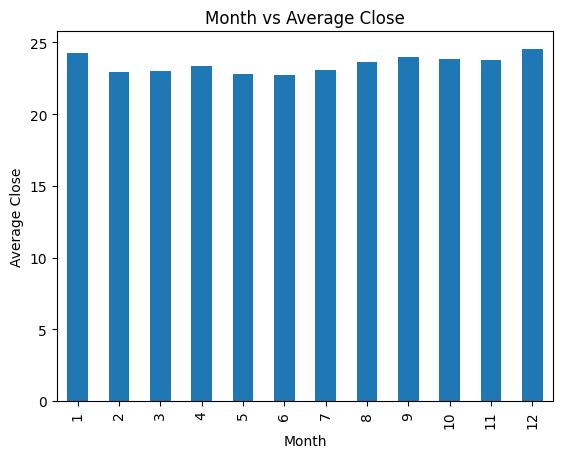

In [ ]:
# ============================================
# ASSIGNMENT: EDA — CATEGORICAL FEATURE ANALYSIS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== DATASET LOADED ====")
print(df.head())

# --------------------------------------------
# Step 3: Convert Date and Extract Categories
# --------------------------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

# --------------------------------------------
# Step 4: Identify Categorical Features
# --------------------------------------------
cat_cols = ['Year', 'Month']  # derived categorical features

print("\nCategorical Features:", cat_cols)

# --------------------------------------------
# Step 5: Value Counts
# --------------------------------------------
for col in cat_cols:
    print(f"\n===== VALUE COUNTS: {col} ====")
    print(df[col].value_counts())

# --------------------------------------------
# Step 6: Bar Charts
# --------------------------------------------
for col in cat_cols:
    plt.figure()
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# --------------------------------------------
# Step 7: Group Analysis (Category vs Target)
# --------------------------------------------
target = 'Close'

for col in cat_cols:
    print(f"\n===== AVERAGE {target} BY {col} ====")
    print(df.groupby(col)[target].mean())

    df.groupby(col)[target].mean().plot(kind='bar')
    plt.title(f"{col} vs Average {target}")
    plt.xlabel(col)
    plt.ylabel(f"Average {target}")
    plt.show()


===== DATASET LOADED ====
         Date      Close       High        Low       Open  Volume
0  2011-01-24  27.318001  27.459999  26.955000  27.174999     168
1  2011-01-25  26.811001  26.950001  26.565001  26.915001      77
2  2011-01-26  27.132000  27.025000  26.684999  27.025000      49
3  2011-01-27  27.045000  27.684999  27.410000  27.684999     184
4  2011-01-28  27.934000  27.950001  26.504999  26.695000      64

Numerical Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

===== CORRELATION MATRIX ====
           Close      High       Low      Open    Volume
Close   1.000000  0.999133  0.999354  0.998465 -0.002250
High    0.999133  1.000000  0.998622  0.999381 -0.003069
Low     0.999354  0.998622  1.000000  0.998890 -0.001192
Open    0.998465  0.999381  0.998890  1.000000 -0.002241
Volume -0.002250 -0.003069 -0.001192 -0.002241  1.000000


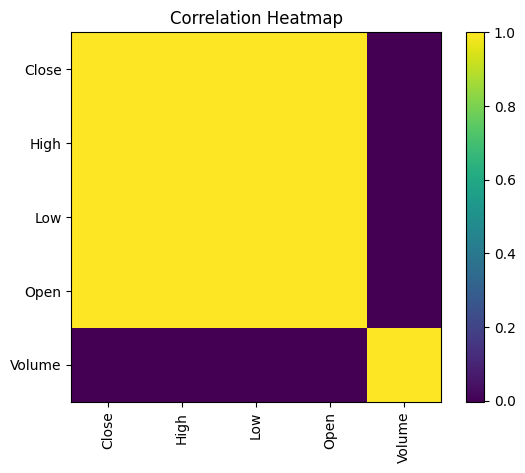

In [ ]:
# ============================================
# ASSIGNMENT: CORRELATION ANALYSIS & HEATMAP
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load Dataset
df = pd.read_csv('silver_prices_data.csv')

print("\n===== DATASET LOADED ====")
print(df.head())

# --------------------------------------------
# Step 3: Select Numerical Columns
# --------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:", list(num_cols))

# --------------------------------------------
# Step 4: Correlation Matrix
# --------------------------------------------
corr_matrix = df[num_cols].corr()

print("\n===== CORRELATION MATRIX ====")
print(corr_matrix)

# --------------------------------------------
# Step 5: Heatmap Visualization
# --------------------------------------------
plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)

plt.title("Correlation Heatmap")
plt.show()